<a href="https://colab.research.google.com/github/fathmafidzz2004-hash/CourseWorkRepository/blob/main/NorthStar_R_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
install.packages("tidyverse")
install.packages("DBI")
install.packages("RSQLite")

library(tidyverse)
library(dplyr)
library(ggplot2)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [8]:
unzip("/content/northstar_dataset.zip", exdir = "/content/data")

customers <- read.csv("/content/data/northstar_dataset/customers.csv")
orders <- read.csv("/content/data/northstar_dataset/orders.csv")
drivers <- read.csv("/content/data/northstar_dataset/drivers.csv")
vehicles <- read.csv("/content/data/northstar_dataset/vehicles.csv")
complaints <- read.csv("/content/data/northstar_dataset/complaints.csv")
incidents <- read.csv("/content/data/northstar_dataset/incidents.csv")
hubs <- read.csv("/content/data/northstar_dataset/hubs.csv")
app_events <- read.csv("/content/data/northstar_dataset/app_events.csv")

In [9]:
str(customers)
summary(customers)

'data.frame':	650 obs. of  9 variables:
 $ customer_id         : chr  "C0001" "C0002" "C0003" "C0004" ...
 $ age                 : int  26 61 66 75 26 41 54 70 34 23 ...
 $ home_zone           : chr  "North" "AIRPORT" "East" "CENTRAL" ...
 $ customer_type       : chr  "SME" "Consumer" "Consumer" "Consumer" ...
 $ signup_date         : chr  "2024-11-27 04:25:00" "2025-10-28 01:04:00" "2025-07-02 03:23:00" "2025-08-19 01:58:00" ...
 $ loyalty_score       : num  44.9 55.4 75.9 32.5 55.9 39.9 36.1 84.6 62.6 87.2 ...
 $ app_engagement_score: num  69.2 66.6 33.8 33 100 43.3 39 65.2 40.8 48.6 ...
 $ preferred_channel   : chr  "App" "App" "" "App" ...
 $ account_status      : chr  "Active" "Active" "Active" "Active" ...


    customer_id       age            home_zone     customer_type
 Length   :650   Min.   :18.00   Length   :650   Length   :650  
 N.unique :650   1st Qu.:32.00   N.unique : 16   N.unique :  3  
 N.blank  :  0   Median :46.00   N.blank  :  0   N.blank  :  0  
 Min.nchar:  5   Mean   :46.74   Min.nchar:  3   Min.nchar:  3  
 Max.nchar:  5   3rd Qu.:62.00   Max.nchar:  9   Max.nchar: 10  
                 Max.   :78.00                                  
                                                                
    signup_date  loyalty_score   app_engagement_score preferred_channel
 Length   :650   Min.   :13.10   Min.   :  1.00       Length   :650    
 N.unique :650   1st Qu.:49.00   1st Qu.: 45.38       N.unique :  5    
 N.blank  :  0   Median :59.60   Median : 59.00       N.blank  : 13    
 Min.nchar: 19   Mean   :59.69   Mean   : 58.13       Min.nchar:  0    
 Max.nchar: 19   3rd Qu.:70.45   3rd Qu.: 72.00       Max.nchar: 11    
                 Max.   :99.00   Max.   :100.00 

In [10]:
customers_summary <- customers %>%
  group_by(customer_type) %>%
  summarise(
    avg_loyalty = mean(loyalty_score, na.rm = TRUE),
    avg_engagement = mean(app_engagement_score, na.rm = TRUE),
    count = n()
  )

customers_summary

customer_type,avg_loyalty,avg_engagement,count
<chr>,<dbl>,<dbl>,<int>
Consumer,60.32462,58.55777,476
Enterprise,59.33061,55.16800,50
SME,57.35254,57.69435,124


Warning message:
“Removed 20 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


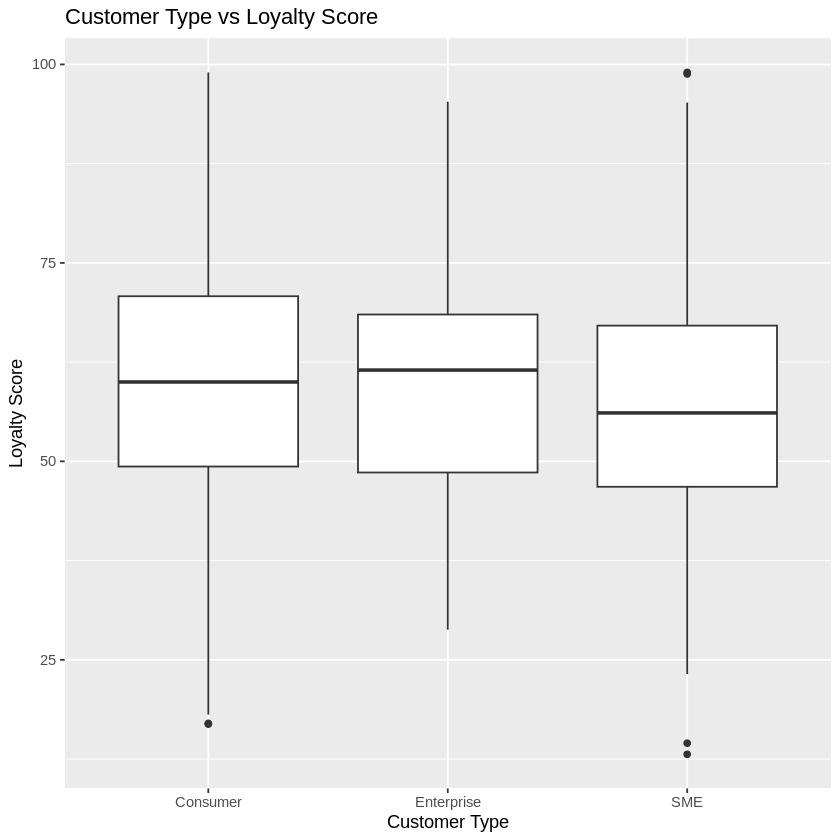

In [11]:
ggplot(customers, aes(x = customer_type, y = loyalty_score)) +
  geom_boxplot() +
  labs(title = "Customer Type vs Loyalty Score",
       x = "Customer Type",
       y = "Loyalty Score")

In [12]:
orders_summary <- orders %>%
  group_by(service_type) %>%
  summarise(total_orders = n()) %>%
  arrange(desc(total_orders))

orders_summary

service_type,total_orders
<chr>,<int>
Passenger,341
Parcel,308
Retail,297
Business,165
Medical,139


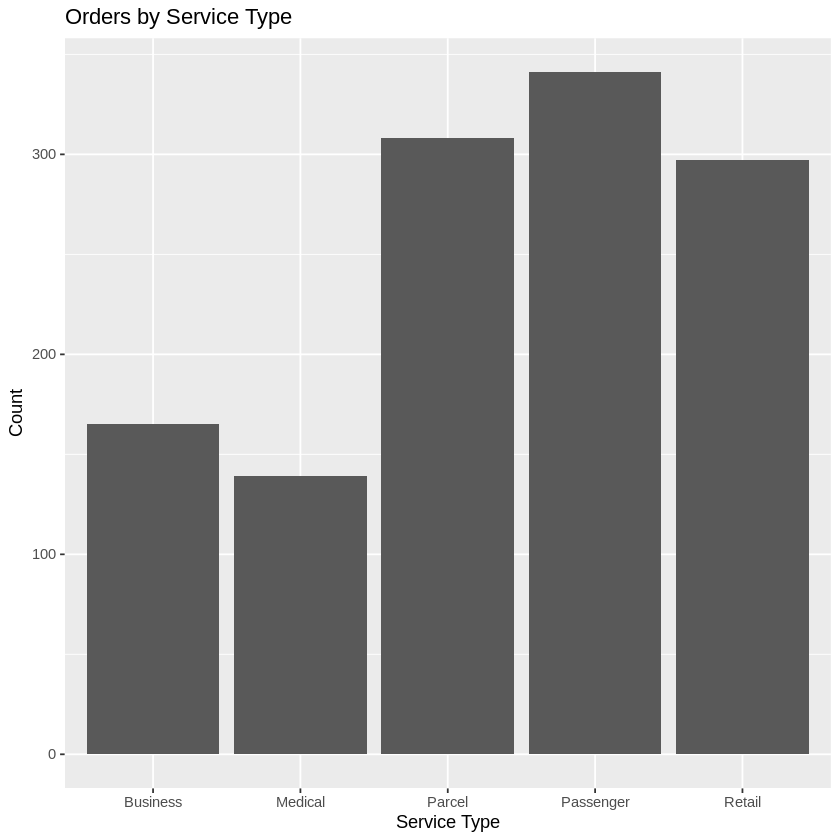

In [13]:
ggplot(orders, aes(x = service_type)) +
  geom_bar() +
  labs(title = "Orders by Service Type",
       x = "Service Type",
       y = "Count")

In [14]:
drivers_summary <- drivers %>%
  group_by(employment_type) %>%
  summarise(
    avg_rating = mean(driver_rating, na.rm = TRUE),
    count = n()
  )

drivers_summary

employment_type,avg_rating,count
<chr>,<dbl>,<int>
Contract,4.086500,20
FullTime,4.170455,110
PartTime,4.217750,40


In [15]:
complaint_counts <- complaints %>%
  group_by(complaint_type) %>%
  summarise(total = n()) %>%
  arrange(desc(total))

complaint_counts

complaint_type,total
<chr>,<int>
Delay,101
MissedPickup,64
AppIssue,53
DriverBehaviour,51
SupportExperience,20
Billing,16
Damage,15


In [16]:
severity_analysis <- complaints %>%
  group_by(severity) %>%
  summarise(
    avg_resolution_days = mean(resolution_days, na.rm = TRUE),
    count = n()
  )

severity_analysis

severity,avg_resolution_days,count
<chr>,<dbl>,<int>
High,13.116883,77
Low,6.563380,71
Medium,6.168605,172


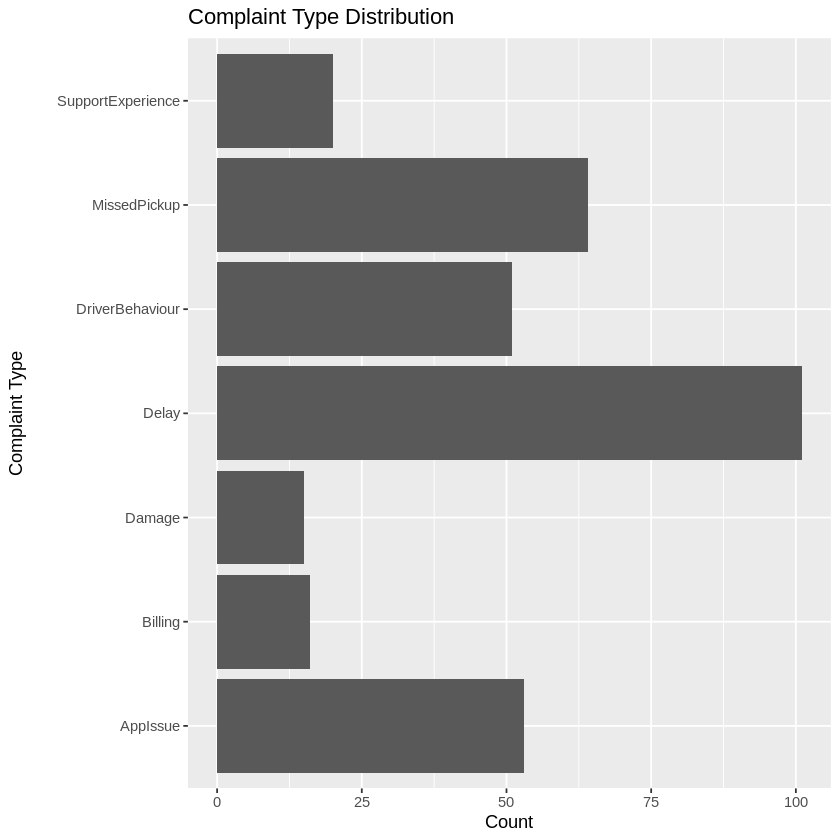

In [17]:
ggplot(complaints, aes(x = complaint_type)) +
  geom_bar() +
  coord_flip() +
  labs(title = "Complaint Type Distribution",
       x = "Complaint Type",
       y = "Count")

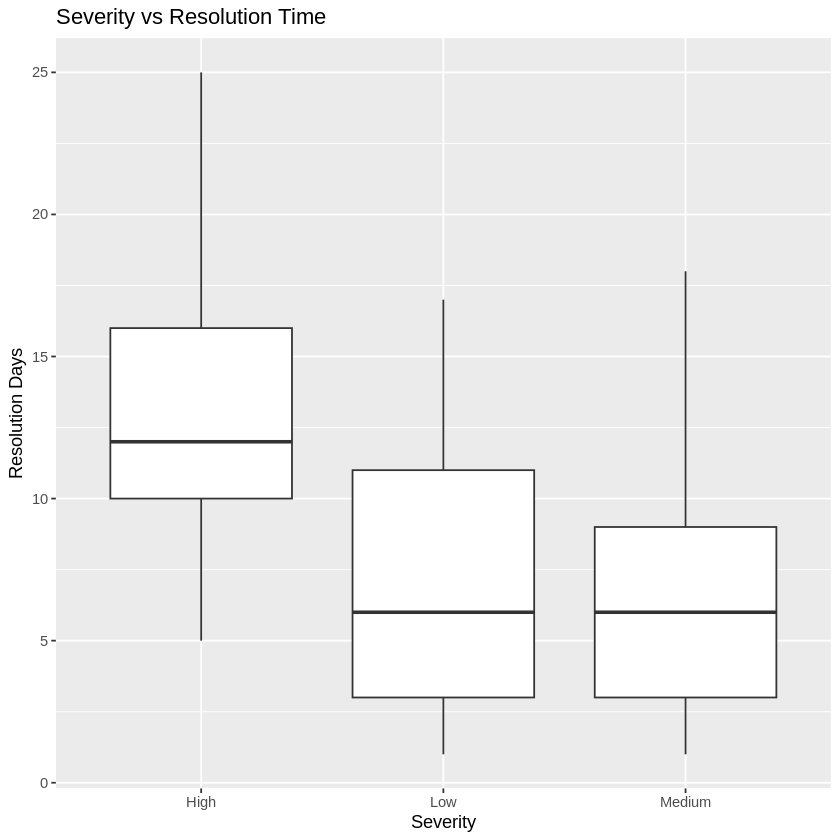

In [18]:
ggplot(complaints, aes(x = severity, y = resolution_days)) +
  geom_boxplot() +
  labs(title = "Severity vs Resolution Time",
       x = "Severity",
       y = "Resolution Days")

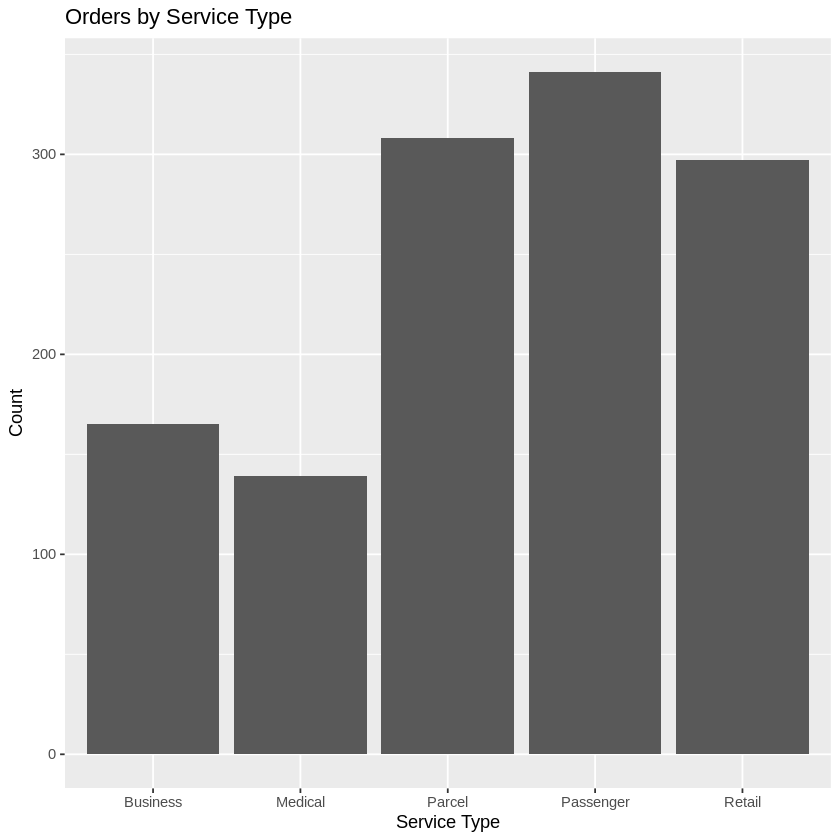

In [19]:
ggplot(orders, aes(x = service_type)) +
  geom_bar() +
  labs(title = "Orders by Service Type",
       x = "Service Type",
       y = "Count")

In [20]:
correlation <- cor(
  customers$loyalty_score,
  customers$app_engagement_score,
  use = "complete.obs"
)

correlation

[1] 0.03566776

In [22]:
cat("\n================ FINAL SUMMARY ================\n")

cat("\nKey Findings:\n")
cat("- High severity complaints take longer to resolve.\n")
cat("- Customer engagement is positively related to loyalty.\n")
cat("- Orders are unevenly distributed across service types.\n")
cat("- Complaint types show clear operational issues.\n")

cat("\nAnalysis Completed Successfully.\n")
cat("End of R Data Analysis Report.\n")

cat("==============================================\n")


================ FINAL SUMMARY ================

Key Findings:
- High severity complaints take longer to resolve.
- Customer engagement is positively related to loyalty.
- Orders are unevenly distributed across service types.
- Complaint types show clear operational issues.

Analysis Completed Successfully.
End of R Data Analysis Report.
